In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('results/combined.csv')
df

,config,task,property,expected,returned,timeout,runtime,solver_walltime,rhs_evals
0,wbu.json,loop-simple/deep-nested.yml,termination,True,unknown,False,20.94,19.537,27958.0
1,wbu.json,loop-simple/deep-nested.yml,unreach-call,False,unknown,False,4.63,4.036,17133.0
2,wbu.json,loop-simple/nested_1.yml,no-overflow,True,true,False,0.16,0.016,125.0
3,wbu.json,loop-simple/nested_1.yml,termination,True,true,False,0.13,0.026,139.0
4,wbu.json,loop-simple/nested_1.yml,unreach-call,True,true,False,0.15,0.024,125.0
...,...,...,...,...,...,...,...,...,...
83,td3.json,loop-simple/nested_5.yml,no-overflow,True,true,False,2.89,NaN,NaN
84,td3.json,loop-simple/nested_5.yml,termination,True,true,False,46.71,NaN,NaN
85,td3.json,loop-simple/nested_5.yml,unreach-call,True,true,False,2.55,NaN,NaN
86,td3.json,loop-simple/nested_6.yml,termination,True,unknown,True,60.04,NaN,NaN


In [2]:
def classify(row):
    ret = str(row['returned']).lower()
    exp = str(row['expected']).lower()
    if ret in ('true', 'false') and ret == exp:
        return 'right'
    elif ret in ('true', 'false'):
        return 'wrong'
    else:
        return 'unknown'

df['verdict'] = df.apply(classify, axis=1)

## Summary: right / wrong per config

In [3]:
summary = (
    df.groupby(['config', 'verdict'])
      .size()
      .unstack(fill_value=0)
      .reindex(columns=['right', 'wrong', 'unknown'], fill_value=0)
)
summary

verdict,right,wrong,unknown
config,,,
bu.json,16,0,6
fwd.json,14,0,8
td3.json,18,0,4
wbu.json,16,0,6


## Cactus plot: tasks solved vs simulated timeout

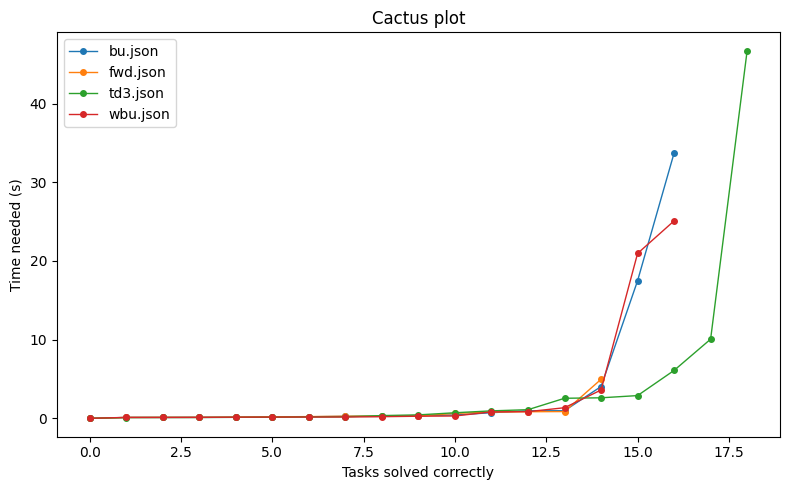

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))

for cfg, group in df.groupby('config'):
    right = group[group['verdict'] == 'right'].sort_values('runtime')
    n_solved = list(range(len(right) + 1))
    time_needed = [0] + list(right['runtime'])
    ax.plot(n_solved, time_needed, marker='o', markersize=4, linewidth=1, label=cfg)

ax.set_xlabel('Tasks solved correctly')
ax.set_ylabel('Time needed (s)')
ax.set_title('Cactus plot')
ax.legend()
plt.tight_layout()
plt.show()